In [25]:
# ============================================================================
# CELL 1: Check Current Environment
# ============================================================================
import importlib

def ver(pkg):
    try:
        m = importlib.import_module(pkg)
        print(f"{pkg}: {getattr(m, '__version__', 'installed')}")
    except Exception as e:
        print(f"{pkg}: NOT INSTALLED")

print("=== Current Environment ===")
ver('torch')
ver('torchvision')
ver('torchaudio')

try:
    import torch
    print(f"\ntorch.version.cuda: {torch.version.cuda}")
    print(f"CUDA available: {torch.cuda.is_available()}")
    print(f"GPU count: {torch.cuda.device_count()}")
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")
except Exception as e:
    print(f"Error: {e}")

=== Current Environment ===
torch: 2.6.0+cu124
torchvision: 0.21.0+cu124
torchaudio: 2.6.0+cu124

torch.version.cuda: 12.4
CUDA available: True
GPU count: 2
GPU: Tesla T4


In [26]:
# ============================================================================
# CELL 2: Clean Install PyTorch cu121
# ============================================================================
print("=== Cleaning and Installing PyTorch cu121 ===")

# Remove existing PyTorch
! pip uninstall -y torch torchvision torchaudio 2>/dev/null || true
!pip cache purge 2>/dev/null || true

# Install matching cu121 versions
!pip install --index-url https://download.pytorch.org/whl/cu121 \
    torch==2.5.1+cu121 \
    torchvision==0.20.1+cu121 \
    torchaudio==2.5.1+cu121

print("\n✓ PyTorch cu121 installed")

=== Cleaning and Installing PyTorch cu121 ===
Found existing installation: torch 2.5.1+cu121
Uninstalling torch-2.5.1+cu121:
  Successfully uninstalled torch-2.5.1+cu121
Found existing installation: torchvision 0.20.1+cu121
Uninstalling torchvision-0.20.1+cu121:
  Successfully uninstalled torchvision-0.20.1+cu121
Found existing installation: torchaudio 2.5.1+cu121
Uninstalling torchaudio-2.5.1+cu121:
  Successfully uninstalled torchaudio-2.5.1+cu121
Files removed: 130
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.5/780.5 MB 2.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 101.4 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 75.6 MB/s eta 0:00:00:00:01

✓ PyTorch cu121 installed


In [27]:
# ============================================================================
# CELL 3: Install torchsparse from Pre-built Wheel
# ============================================================================
# Option A: If you have the wheel in a Kaggle dataset
!pip install /kaggle/input/torchsparse-cu121-t4/torchsparse-2.1.0-cp311-cp311-linux_x86_64.whl

# Verify
import torchsparse
print(f"\n✓ torchsparse {torchsparse.__version__} installed")

Processing /kaggle/input/torchsparse-cu121-t4/torchsparse-2.1.0-cp311-cp311-linux_x86_64.whl
torchsparse is already installed with the same version as the provided wheel. Use --force-reinstall to force an installation of the wheel.

✓ torchsparse 2.1.0 installed


In [28]:
# ============================================================================
# CELL 4: Install Remaining Dependencies
# ============================================================================
print("=== Installing Dependencies ===")

# Fix numpy version for sklearn compatibility
!pip install "numpy<2.0"

# Install required packages
!pip install transformers accelerate huggingface_hub
!pip install open3d einops

# Verify installations
import numpy as np
import torch
import torchsparse
import transformers

print("\n=== Verification ===")
print(f"✓ numpy: {np.__version__}")
print(f"✓ torch: {torch.__version__}")
print(f"✓ torch.version.cuda: {torch.version.cuda}")
print(f"✓ torchsparse: {torchsparse.__version__}")
print(f"✓ transformers: {transformers.__version__}")
print(f"✓ CUDA available: {torch.cuda.is_available()}")
print(f"✓ GPU count: {torch.cuda.device_count()}")

=== Installing Dependencies ===

=== Verification ===
✓ numpy: 1.26.4
✓ torch: 2.6.0+cu124
✓ torch.version.cuda: 12.4
✓ torchsparse: 2.1.0
✓ transformers: 4.53.3
✓ CUDA available: True
✓ GPU count: 2


In [29]:
# ============================================================================
# CELL 5: Clone SpatialLM Repository
# ============================================================================
import os
os.chdir('/kaggle/working')

!git clone https://github.com/manycore-research/SpatialLM.git 2>/dev/null || echo "Already cloned"
os.chdir('/kaggle/working/SpatialLM')

print(f"Working directory: {os.getcwd()}")
! ls -la

Already cloned
Working directory: /kaggle/working/SpatialLM
total 128
drwxr-xr-x 8 root root  4096 Dec  3 11:16 .
drwxr-xr-x 4 root root  4096 Dec  3 11:09 ..
drwxr-xr-x 3 root root  4096 Dec  3 11:11 .cache
-rw-r--r-- 1 root root   562 Dec  3 11:09 code_template.txt
drwxr-xr-x 2 root root  4096 Dec  3 11:09 configs
-rw-r--r-- 1 root root 18077 Dec  3 11:09 eval.py
-rw-r--r-- 1 root root  6594 Dec  3 11:09 EXAMPLE.md
drwxr-xr-x 2 root root  4096 Dec  3 11:09 figures
-rw-r--r-- 1 root root  4927 Dec  3 11:09 FINETUNE.md
drwxr-xr-x 8 root root  4096 Dec  3 11:09 .git
-rw-r--r-- 1 root root  3179 Dec  3 11:09 .gitignore
-rw-r--r-- 1 root root  9893 Dec  3 11:09 inference.py
-rw-r--r-- 1 root root  7712 Dec  3 11:09 LICENSE.txt
drwxr-xr-x 2 root root  4096 Dec  3 11:11 pcd
-rw-r--r-- 1 root root  1660 Dec  3 11:09 pyproject.toml
-rw-r--r-- 1 root root 18472 Dec  3 11:09 README.md
-rw-r--r-- 1 root root     0 Dec  3 11:16 scene0000_00.txt
drwxr-xr-x 7 root root  4096 Dec  3 11:11 spatiallm


In [30]:
# ============================================================================
# CELL 6: Download Sample Point Cloud
# ============================================================================
print("=== Downloading Sample Data ===")

! huggingface-cli download manycore-research/SpatialLM-Testset pcd/scene0000_00.ply --repo-type dataset --local-dir .

! ls -lh pcd/

=== Downloading Sample Data ===
⚠️  Warning: 'huggingface-cli download' is deprecated. Use 'hf download' instead.
pcd/scene0000_00.ply
total 11M
-rw-r--r-- 1 root root 11M Dec  3 11:11 scene0000_00.ply


In [31]:
# ============================================================================
# CELL 7: Run Inference with SpatialLM 1.0
# ============================================================================
print("=== Running Inference with SpatialLM 1.0 ===")

# Use SpatialLM 1.0 models (NOT 1.1 - they require sonata)
# Options:
#   - manycore-research/SpatialLM-Qwen-0.5B  (smaller, faster)
#   - manycore-research/SpatialLM-Llama-1B  (larger, more accurate)

!python inference.py --point_cloud pcd/scene0000_00.ply --output scene0000_00.txt --model_path manycore-research/SpatialLM-Qwen-0.5B

print("\n✓ Inference complete!")

=== Running Inference with SpatialLM 1.0 ===
2025-12-03 11:25:31.267056: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764761131.289422     367 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764761131.297177     367 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'
AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'
AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'
AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'
AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'
/usr/local/lib/python3.11/dist-p

In [32]:
# ============================================================================
# CELL 8: View Results
# ============================================================================
print("=== Layout Prediction Results ===\n")

try:
    with open('scene0000_00.txt', 'r') as f:
        layout = f.read()
        print(layout)
except FileNotFoundError:
    print("❌ Result file not found - check inference output above for errors")

=== Layout Prediction Results ===




Point cloud: 685,513 points
Sampled to 50,000 points for visualization

✓ Saved visualization to point_cloud_visualization.png


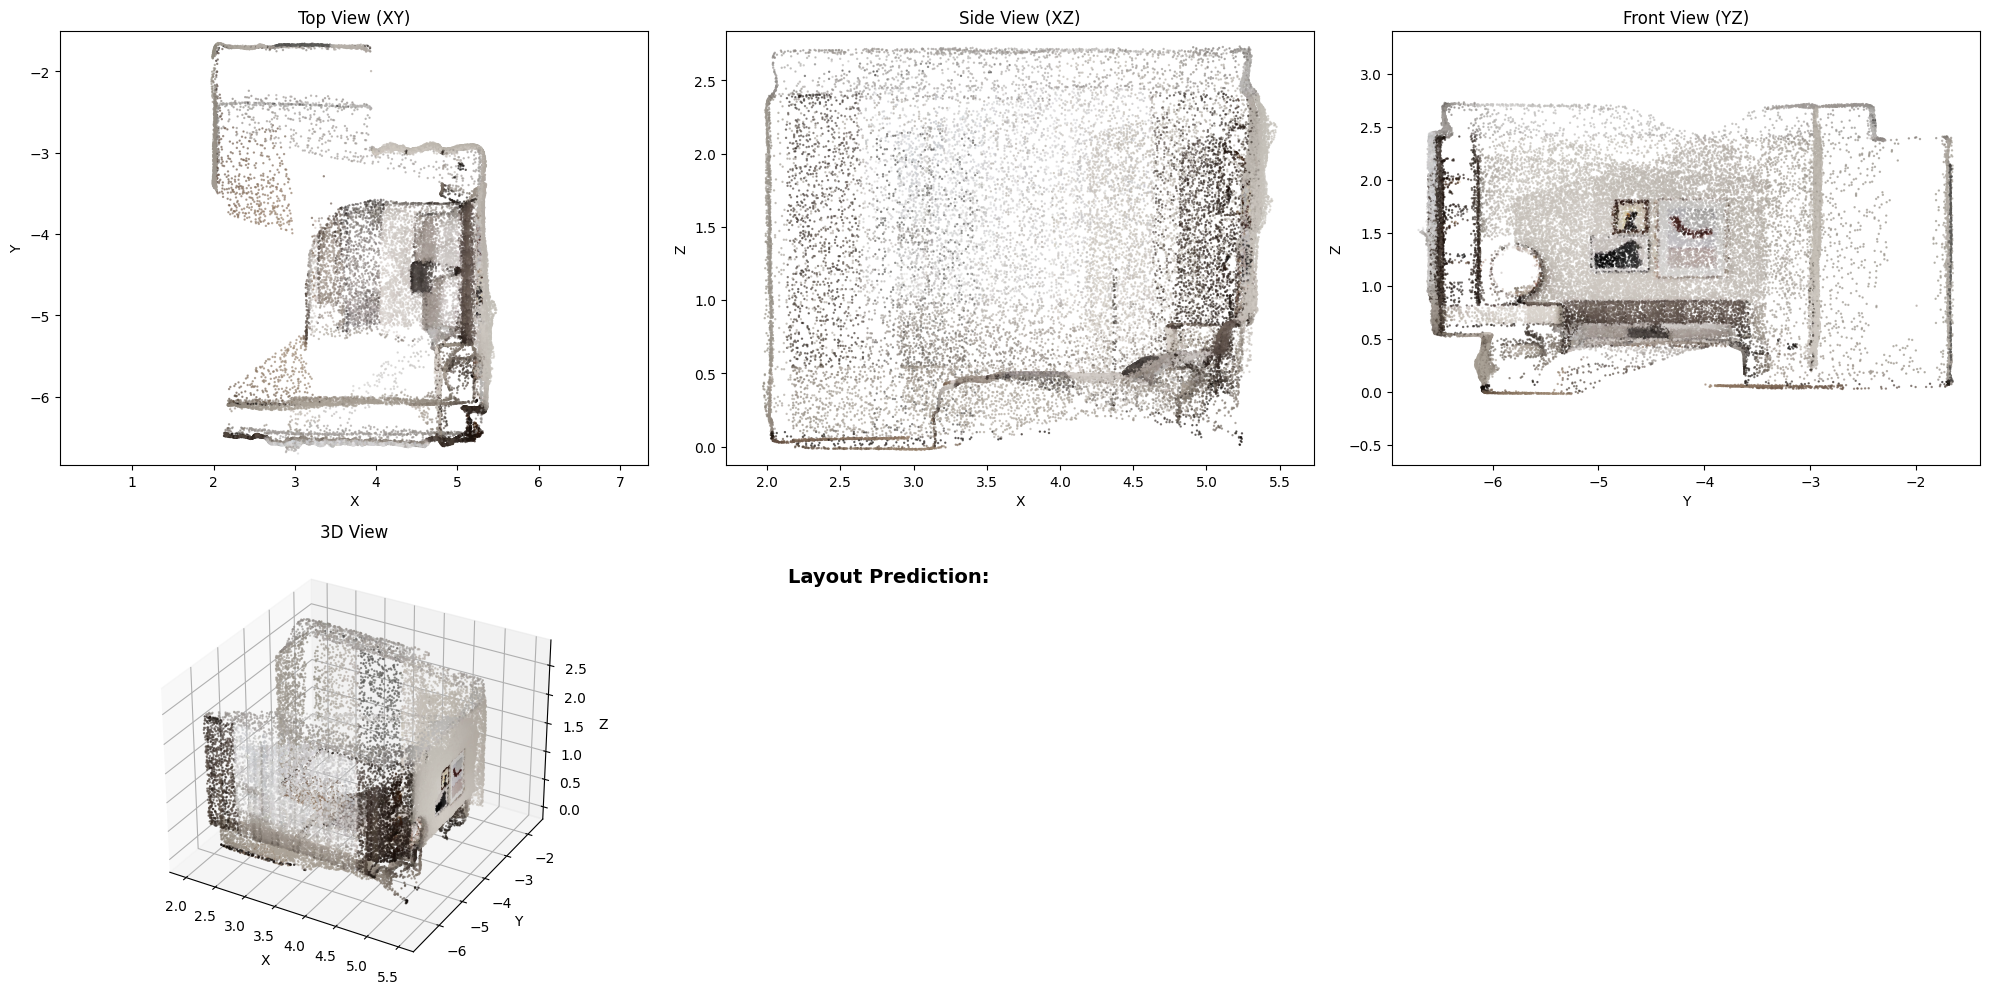

In [33]:
# ============================================================================
# CELL 9: Visualize Point Cloud
# ============================================================================
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

def visualize_point_cloud(ply_file, layout_file=None, max_points=50000):
    """Visualize point cloud with optional layout predictions"""
    
    # Load point cloud
    pcd = o3d.io.read_point_cloud(ply_file)
    points = np.asarray(pcd.points)
    colors = np.asarray(pcd.colors)
    
    print(f"Point cloud: {points.shape[0]:,} points")
    
    # Sample for visualization (memory limit)
    if points.shape[0] > max_points:
        indices = np.random.choice(points.shape[0], max_points, replace=False)
        points = points[indices]
        colors = colors[indices]
        print(f"Sampled to {max_points:,} points for visualization")
    
    # Create figure
    fig = plt.figure(figsize=(20, 10))
    
    # Top view (XY plane)
    ax1 = fig.add_subplot(231)
    ax1.scatter(points[:, 0], points[:, 1], c=colors, s=0.5, alpha=0.6)
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_title('Top View (XY)')
    ax1.axis('equal')
    
    # Side view (XZ plane)
    ax2 = fig.add_subplot(232)
    ax2.scatter(points[:, 0], points[:, 2], c=colors, s=0.5, alpha=0.6)
    ax2.set_xlabel('X')
    ax2.set_ylabel('Z')
    ax2.set_title('Side View (XZ)')
    ax2.axis('equal')
    
    # Front view (YZ plane)
    ax3 = fig.add_subplot(233)
    ax3.scatter(points[:, 1], points[:, 2], c=colors, s=0.5, alpha=0.6)
    ax3.set_xlabel('Y')
    ax3.set_ylabel('Z')
    ax3.set_title('Front View (YZ)')
    ax3.axis('equal')
    
    # 3D view
    ax4 = fig.add_subplot(234, projection='3d')
    ax4.scatter(points[:, 0], points[:, 1], points[:, 2], 
               c=colors, s=0.5, alpha=0.6)
    ax4.set_xlabel('X')
    ax4.set_ylabel('Y')
    ax4.set_zlabel('Z')
    ax4.set_title('3D View')
    
    # Layout predictions text
    ax5 = fig.add_subplot(2, 3, (5, 6))
    ax5.axis('off')
    
    if layout_file and os.path.exists(layout_file):
        with open(layout_file, 'r') as f:
            layout_text = f.read()
        ax5.text(0.05, 0.95, "Layout Prediction:", 
                transform=ax5.transAxes, fontsize=14, fontweight='bold',
                verticalalignment='top')
        ax5.text(0.05, 0.85, layout_text[:2000],  # Limit text length
                transform=ax5.transAxes, fontsize=9,
                verticalalignment='top', family='monospace',
                wrap=True)
    else:
        ax5.text(0.5, 0.5, "No layout predictions available", 
                transform=ax5.transAxes, fontsize=12,
                ha='center', va='center')
    
    plt.tight_layout()
    
    # Save
    output_file = 'point_cloud_visualization.png'
    plt.savefig(output_file, dpi=150, bbox_inches='tight')
    print(f"\n✓ Saved visualization to {output_file}")
    plt.show()

# Run visualization
visualize_point_cloud("pcd/scene0000_00.ply", "scene0000_00.txt")

In [41]:
# ============================================================================
# CELL 10: Batch Processing Function
# ============================================================================
import os
from pathlib import Path

def batch_process(input_dir, output_dir, model="manycore-research/SpatialLM-Qwen-0.5B"):
    """Process all .ply files in a directory"""
    
    input_path = Path(input_dir)
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    
    # Find all .ply files
    ply_files = list(input_path.glob("*.ply"))
    
    if not ply_files:
        print(f"❌ No .ply files found in {input_dir}")
        return
    
    print(f"Found {len(ply_files)} point clouds to process\n")
    
    results = []
    for i, ply_file in enumerate(ply_files, 1):
        output_file = output_path / f"{ply_file.stem}_layout.txt"
        
        print(f"[{i}/{len(ply_files)}] Processing {ply_file.name}...")
        
        # Run inference
        cmd = f"python inference.py --point_cloud {ply_file} --output {output_file} --model_path {model}"
        exit_code = os.system(cmd)
        
        if exit_code == 0 and output_file.exists():
            print(f"    ✓ Saved to {output_file.name}\n")
            results.append((ply_file.name, "SUCCESS"))
        else:
            print(f"    ❌ Failed\n")
            results.append((ply_file.name, "FAILED"))
    
    # Summary
    print("=" * 60)
    print("BATCH PROCESSING SUMMARY")
    print("=" * 60)
    for filename, status in results:
        status_icon = "✓" if status == "SUCCESS" else "❌"
        print(f"{status_icon} {filename:<40} {status}")
    print("=" * 60)
    
    success_count = sum(1 for _, status in results if status == "SUCCESS")
    print(f"\n✓ {success_count}/{len(results)} files processed successfully")
    print(f"Results saved to: {output_path}")

# Example usage (uncomment to run):
# batch_process("pcd/", "results/")

In [35]:
# ============================================================================
# CELL 11: Process Your Own Point Clouds
# ============================================================================
print("""
╔═══════════════════════════════════════════════════════════════╗
║              USING YOUR OWN POINT CLOUDS                      ║
╚═══════════════════════════════════════════════════════════════╝

1.UPLOAD YOUR DATA:
   - Create a Kaggle dataset with your .ply files
   - Add it to this notebook (click "Add Data" button)
   - Your files will be at: /kaggle/input/your-dataset-name/

2.SINGLE FILE INFERENCE:
   ! python inference.py \\
       --point_cloud /kaggle/input/your-dataset/scene.ply \\
       --output my_result.txt \\
       --model_path manycore-research/SpatialLM-Qwen-0.5B

3.BATCH PROCESSING:
   batch_process(
       input_dir="/kaggle/input/your-dataset/",
       output_dir="/kaggle/working/results/"
   )

4.POINT CLOUD REQUIREMENTS:
   ├─ Format: .ply (ASCII or binary)
   ├─ Coordinate system: z-up
   ├─ Scale: metric (room height ~2.5m)
   └─ Coverage: full scene visible

5.AVAILABLE MODELS (SpatialLM 1.0):
   ├─ manycore-research/SpatialLM-Qwen-0.5B  (faster, less VRAM)
   └─ manycore-research/SpatialLM-Llama-1B  (more accurate)

   ⚠️  DO NOT use SpatialLM1.1 models - they require sonata
""")


╔═══════════════════════════════════════════════════════════════╗
║              USING YOUR OWN POINT CLOUDS                      ║
╚═══════════════════════════════════════════════════════════════╝

1.UPLOAD YOUR DATA:
   - Create a Kaggle dataset with your .ply files
   - Add it to this notebook (click "Add Data" button)
   - Your files will be at: /kaggle/input/your-dataset-name/

2.SINGLE FILE INFERENCE:
   ! python inference.py \
       --point_cloud /kaggle/input/your-dataset/scene.ply \
       --output my_result.txt \
       --model_path manycore-research/SpatialLM-Qwen-0.5B

3.BATCH PROCESSING:
   batch_process(
       input_dir="/kaggle/input/your-dataset/",
       output_dir="/kaggle/working/results/"
   )

4.POINT CLOUD REQUIREMENTS:
   ├─ Format: .ply (ASCII or binary)
   ├─ Coordinate system: z-up
   ├─ Scale: metric (room height ~2.5m)
   └─ Coverage: full scene visible

5.AVAILABLE MODELS (SpatialLM 1.0):
   ├─ manycore-research/SpatialLM-Qwen-0.5B  (faster, less VRAM)
 

In [36]:
# ============================================================================
# CELL 12: Export Results
# ============================================================================
import zipfile
import os
from datetime import datetime

def export_results(results_dir=".", patterns=["*.txt", "*.png"], output_name=None):
    """Package results into a zip file for download"""
    
    if output_name is None:
        output_name = f"spatiallm_results_{datetime.now().strftime('%Y%m%d_%H%M%S')}.zip"
    
    files_to_zip = []
    for pattern in patterns:
        files_to_zip.extend(Path(results_dir).glob(pattern))
    
    if not files_to_zip:
        print(f"❌ No files matching {patterns} found in {results_dir}")
        return
    
    # Create zip file
    with zipfile.ZipFile(output_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for file_path in files_to_zip:
            arcname = file_path.name
            zipf.write(file_path, arcname)
            print(f"Added: {arcname}")
    
    size = os.path.getsize(output_name) / 1024
    print(f"\n✓ Created {output_name} ({size:.1f} KB)")
    print(f"Download from: /kaggle/working/{output_name}")
    
    return output_name

# Export current results
export_results(".", ["scene*.txt", "*.png"])

Added: scene0000_00.txt
Added: point_cloud_visualization.png

✓ Created spatiallm_results_20251203_112829.zip (1914.0 KB)
Download from: /kaggle/working/spatiallm_results_20251203_112829.zip


'spatiallm_results_20251203_112829.zip'

In [37]:
# ============================================================================
# CELL 13: Utility Functions
# ============================================================================
import torch

def check_gpu_memory():
    """Check GPU memory usage"""
    if torch.cuda.is_available():
        for i in range(torch.cuda.device_count()):
            props = torch.cuda.get_device_properties(i)
            total = props.total_memory / 1024**3
            used = torch.cuda.memory_allocated(i) / 1024**3
            cached = torch.cuda.memory_reserved(i) / 1024**3
            print(f"GPU {i} ({props.name}):")
            print(f"  Total:  {total:.1f} GB")
            print(f"  Used:   {used:.1f} GB")
            print(f"  Cached: {cached:.1f} GB")
            print(f"  Free:   {total - cached:.1f} GB")
    else:
        print("No GPU available")

def clear_gpu_cache():
    """Clear GPU cache to free memory"""
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        print("✓ GPU cache cleared")

def check_setup():
    """Verify all components are installed correctly"""
    import sys
    
    checks = {}
    
    # Python
    checks["Python"] = sys.version.split()[0]
    
    # PyTorch
    try:
        import torch
        checks["PyTorch"] = torch.__version__
        checks["PyTorch CUDA"] = torch.version.cuda
        checks["CUDA Available"] = "✓" if torch.cuda.is_available() else "❌"
        checks["GPU Count"] = torch.cuda.device_count()
    except ImportError:
        checks["PyTorch"] = "❌ NOT INSTALLED"
    
    # torchsparse
    try:
        import torchsparse
        checks["torchsparse"] = torchsparse.__version__
    except ImportError:
        checks["torchsparse"] = "❌ NOT INSTALLED"
    
    # transformers
    try:
        import transformers
        checks["transformers"] = transformers.__version__
    except ImportError:
        checks["transformers"] = "❌ NOT INSTALLED"
    
    # numpy
    try:
        import numpy
        checks["numpy"] = numpy.__version__
    except ImportError:
        checks["numpy"] = "❌ NOT INSTALLED"
    
    print("=== Setup Status ===")
    all_ok = True
    for key, value in checks.items():
        status = "❌" if "NOT INSTALLED" in str(value) or value == "❌" else "✓"
        if status == "❌":
            all_ok = False
        print(f"{status} {key:<20} {value}")
    
    return all_ok

# Run setup check
print("\n")
if check_setup():
    print("\n✅ All systems ready!")
else:
    print("\n❌ Setup incomplete - check errors above")

print("\n")
check_gpu_memory()



=== Setup Status ===
✓ Python               3.11.13
✓ PyTorch              2.6.0+cu124
✓ PyTorch CUDA         12.4
✓ CUDA Available       ✓
✓ GPU Count            2
✓ torchsparse          2.1.0
✓ transformers         4.53.3
✓ numpy                1.26.4

✅ All systems ready!


GPU 0 (Tesla T4):
  Total:  14.7 GB
  Used:   0.0 GB
  Cached: 0.0 GB
  Free:   14.7 GB
GPU 1 (Tesla T4):
  Total:  14.7 GB
  Used:   0.0 GB
  Cached: 0.0 GB
  Free:   14.7 GB


In [38]:
# ============================================================================
# CELL 14: Summary
# ============================================================================
print("""
╔═══════════════════════════════════════════════════════════════╗
║                 SPATIALLM 1.0 PIPELINE READY                  ║
╚═══════════════════════════════════════════════════════════════╝

✓ Using SpatialLM 1.0 (no sonata dependency)
✓ torchsparse for point cloud encoding
✓ Compatible with Tesla T4 GPU

QUICK COMMANDS:
───────────────
Single file:
    !python inference.py \\
        --point_cloud input.ply \\
        --output output.txt \\
        --model_path manycore-research/SpatialLM-Qwen-0.5B

Batch process:
    batch_process("input_dir/", "output_dir/")

Visualize:
    visualize_point_cloud("input.ply", "output.txt")

MODELS (SpatialLM 1.0 only):
────────────────────────────
├─ manycore-research/SpatialLM-Qwen-0.5B  ← Recommended for T4
└─ manycore-research/SpatialLM-Llama-1B   ← Higher accuracy

⚠️  DO NOT USE these models (they require sonata):
    - SpatialLM1.1-Qwen-0.5B
    - SpatialLM1.1-Llama-1B

TROUBLESHOOTING:
────────────────
OOM Error:
    clear_gpu_cache()
    # Or downsample point cloud

Check status:
    check_setup()
    check_gpu_memory()
""")


╔═══════════════════════════════════════════════════════════════╗
║                 SPATIALLM 1.0 PIPELINE READY                  ║
╚═══════════════════════════════════════════════════════════════╝

✓ Using SpatialLM 1.0 (no sonata dependency)
✓ torchsparse for point cloud encoding
✓ Compatible with Tesla T4 GPU

QUICK COMMANDS:
───────────────
Single file:
    !python inference.py \
        --point_cloud input.ply \
        --output output.txt \
        --model_path manycore-research/SpatialLM-Qwen-0.5B

Batch process:
    batch_process("input_dir/", "output_dir/")

Visualize:
    visualize_point_cloud("input.ply", "output.txt")

MODELS (SpatialLM 1.0 only):
────────────────────────────
├─ manycore-research/SpatialLM-Qwen-0.5B  ← Recommended for T4
└─ manycore-research/SpatialLM-Llama-1B   ← Higher accuracy

⚠️  DO NOT USE these models (they require sonata):
    - SpatialLM1.1-Qwen-0.5B
    - SpatialLM1.1-Llama-1B

TROUBLESHOOTING:
────────────────
OOM Error:
    clear_gpu_cache()
  